# Regresión Polinomial

In [1]:
from ISLP import  load_data


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [3]:
from ISLP.models import ModelSpec as MS,poly, summarize

In [4]:
wage = load_data('Wage')
wage.shape
wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [5]:
wage[["age","wage"]].describe()

,age,wage
count,3000.000000,3000.000000
mean,42.414667,111.703608
std,11.542406,41.728595
min,18.000000,20.085537
25%,33.750000,85.383940
50%,42.000000,104.921507
75%,51.000000,128.680488
max,80.000000,318.342430


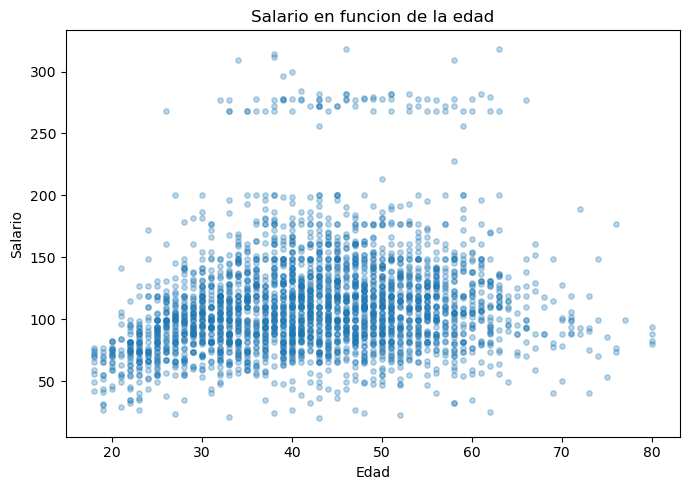

In [6]:
plt.figure(figsize = (7,5))
plt.scatter(wage["age"],wage['wage'], alpha = 0.3, s = 15)
plt.xlabel('Edad')
plt.ylabel('Salario')
plt.title('Salario en funcion de la edad')
plt.tight_layout()
plt.show()

In [7]:
design_g4 = MS([poly('age',degree = 4)])
X_g4 = design_g4.fit_transform(wage)
y = wage['wage']
modelo_g4 = sm.OLS(y,X_g4).fit()
summarize(modelo_g4)

,coef,std err,t,P>|t|
intercept,111.7036,0.729,153.283,0.000
"poly(age, degree=4)[0]",447.0679,39.915,11.201,0.000
"poly(age, degree=4)[1]",-478.3158,39.915,-11.983,0.000
"poly(age, degree=4)[2]",125.5217,39.915,3.145,0.002
"poly(age, degree=4)[3]",-77.9112,39.915,-1.952,0.051


In [8]:
#Creacion de la banda de predicción
age_grid = np.linspace(wage['age'].min(), wage['age'].max(),200)
datos_pred = pd.DataFrame({'age': age_grid})
X_pred = design_g4.transform(datos_pred)
prediccion = modelo_g4.get_prediction(X_pred)

#IC 95%
resumen_pred = prediccion.summary_frame(alpha = 0.05)
resumen_pred.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,51.931450,5.298268,41.542837,62.320064,-27.018198,130.881099
1,54.031077,4.992907,44.241202,63.820952,-24.842019,132.904173
2,56.081359,4.702471,46.860958,65.301760,-22.723079,134.885797
3,58.083102,4.426735,49.403354,66.762851,-20.659908,136.826113
4,60.037106,4.165482,51.869611,68.204602,-18.651086,138.725299


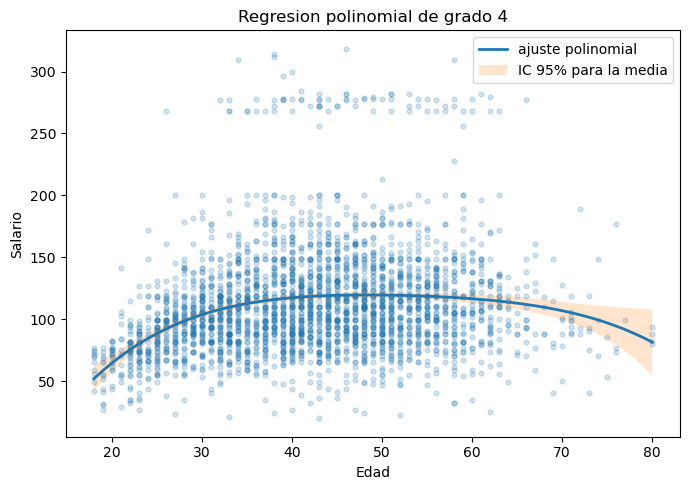

In [9]:
plt.figure(figsize = (7,5))
plt.scatter(wage['age'],wage['wage'], alpha=0.2, s = 12)
plt.plot(age_grid, resumen_pred['mean'],lw = 2, label = 'ajuste polinomial')
plt.fill_between(age_grid, resumen_pred['mean_ci_lower'], resumen_pred['mean_ci_upper'], alpha = 0.2, label = 'IC 95% para la media')
plt.xlabel('Edad')
plt.ylabel("Salario")
plt.title('Regresion polinomial de grado 4')
plt.legend()
plt.tight_layout()
plt.show()

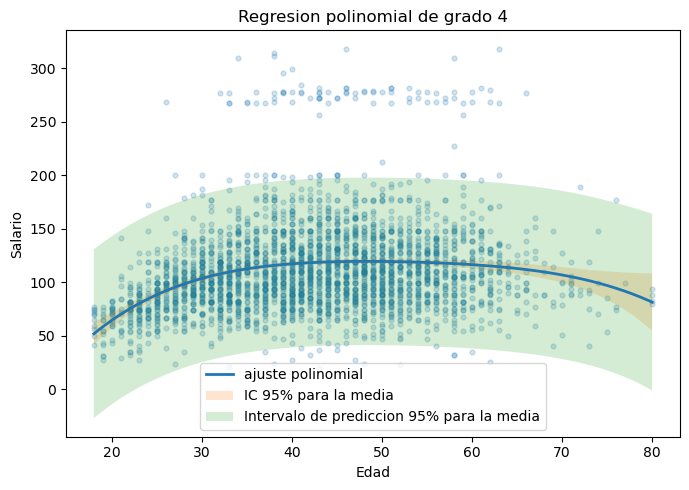

In [10]:
plt.figure(figsize = (7,5))
plt.scatter(wage['age'],wage['wage'], alpha=0.2, s = 12)
plt.plot(age_grid, resumen_pred['mean'],lw = 2, label = 'ajuste polinomial')
plt.fill_between(age_grid, resumen_pred['mean_ci_lower'], resumen_pred['mean_ci_upper'], alpha = 0.2, label = 'IC 95% para la media')
plt.fill_between(age_grid, resumen_pred['obs_ci_lower'], resumen_pred['obs_ci_upper'], alpha = 0.2, label = 'Intervalo de prediccion 95% para la media')
plt.xlabel('Edad')
plt.ylabel("Salario")
plt.title('Regresion polinomial de grado 4')
plt.legend()
plt.tight_layout()
plt.show()

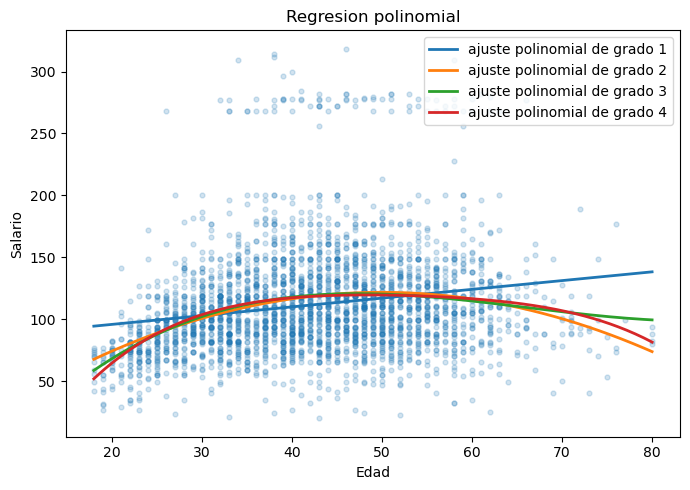

In [11]:

plt.figure(figsize = (7,5))
plt.scatter(wage['age'],wage['wage'], alpha=0.2, s = 12)
for i in range(1,5):
    design_g4 = MS([poly('age',degree = i)])
    X_g4 = design_g4.fit_transform(wage)
    y = wage['wage']
    modelo_g4 = sm.OLS(y,X_g4).fit()
    
    #Creacion de la banda de predicción
    datos_pred = pd.DataFrame({'age': age_grid})
    X_pred = design_g4.transform(datos_pred)
    prediccion = modelo_g4.get_prediction(X_pred)

    #IC 95%
    resumen_pred = prediccion.summary_frame(alpha = 0.05)

   
    
    plt.plot(age_grid, resumen_pred['mean'],lw = 2, label = f'ajuste polinomial de grado {i}')
    plt.xlabel('Edad')
    plt.ylabel("Salario")
    plt.title('Regresion polinomial')
    plt.legend()
    plt.tight_layout()

plt.show()

modelos = {}

for d in range(1,6):
    design_d =MS([poly('age', degree = d)])
    X_d = design_d.fit_transform(wage)
    modelos[d]= sm.OLS(wage['wage'],X_d).fit()

tabla_anova  = sm.stats.anova_lm(
    modelos[1],
    modelos[2],
    modelos[3],
    modelos[4],
    modelos[5])
tabla_anova

In [12]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = wage[['age']].values
y_arr = wage['wage'].values

kf = KFold(
    n_splits = 10,
    shuffle = True,
    random_state = 42
)

grados = range(1,11)
ecm_promedio = []

for d in grados:
    errores_folds = []
    transformador_poly = PolynomialFeatures(degree = d, include_bias = False)

    for idx_train, idx_test in kf.split(X):
        X_train_poly = transformador_poly.fit_transform(X[idx_train])
        X_test_poly = transformador_poly.transform(X[idx_test])
        modelo_cv = LinearRegression().fit(X_train_poly, y_arr[idx_train])
        pred = modelo_cv.predict(X_test_poly)
        errores_folds.append(mean_squared_error(y_arr[idx_test],pred))
    ecm_promedio.append(np.mean(errores_folds))

d_optimo = list(grados)[int(np.argmin(ecm_promedio))]
print(d_optimo)

8


## Regresion logistica

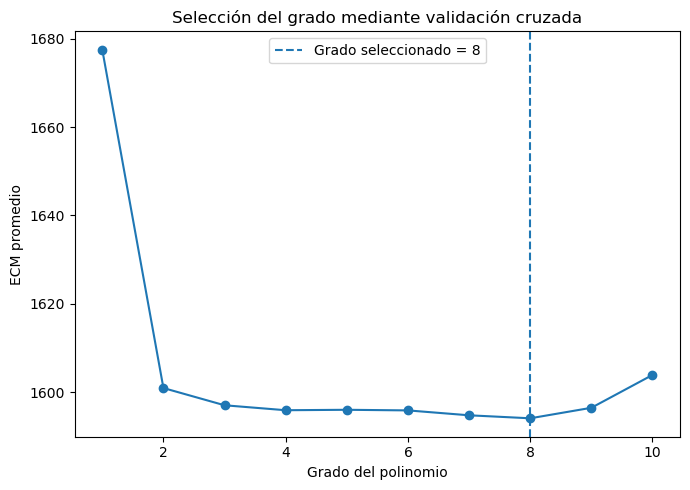

In [13]:
plt.figure(figsize=(7, 5))

plt.plot(
    list(grados),
    ecm_promedio,
    marker='o'
)

plt.axvline(
    d_optimo,
    linestyle='--',
    label=f'Grado seleccionado = {d_optimo}'
)

plt.xlabel('Grado del polinomio')
plt.ylabel('ECM promedio')
plt.title('Selección del grado mediante validación cruzada')

plt.legend()
plt.tight_layout()
plt.show()

In [15]:
wage['salario_alto'] = (wage['wage']>250).astype(int)
wage['salario_alto'].value_counts()

salario_alto
0    2921
1      79
Name: count, dtype: int64

In [20]:
grado = 4
design_logit = MS([poly('age',degree = grado)])
design_logit = design_logit.fit(wage)
X_logit = design_logit.transform(wage)
y_logit = wage['salario_alto']


In [21]:
modelo_logit= sm.GLM(y_logit,X_logit, family = sm.families.Binomial()).fit()
summarize(modelo_logit)

,coef,std err,z,P>|z|
intercept,-4.3012,0.345,-12.457,0.000
"poly(age, degree=4)[0]",71.9642,26.133,2.754,0.006
"poly(age, degree=4)[1]",-85.7729,35.929,-2.387,0.017
"poly(age, degree=4)[2]",34.1626,19.697,1.734,0.083
"poly(age, degree=4)[3]",-47.4008,24.105,-1.966,0.049


In [26]:
age_grid = np.linspace(wage['age'].min(),wage['age'].max(),200)
datos_pred_logit = pd.DataFrame({'age':age_grid})
X_pred_logit = design_logit.transform(datos_pred_logit)
pred_logit = modelo_logit.get_prediction(X_pred_logit)
resumen_logit = pred_logit.summary_frame(alpha = 0.05)
resumen_logit.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper
0,9.826349e-09,6.037272e-08,5.789509e-14,0.001665
1,1.900428e-08,1.113108e-07,1.964454e-13,0.001835
2,3.598553e-08,2.008033e-07,6.402190e-13,0.002019
3,6.674401e-08,3.545879e-07,2.005727e-12,0.002216
4,1.213091e-07,6.131647e-07,6.045581e-12,0.002428


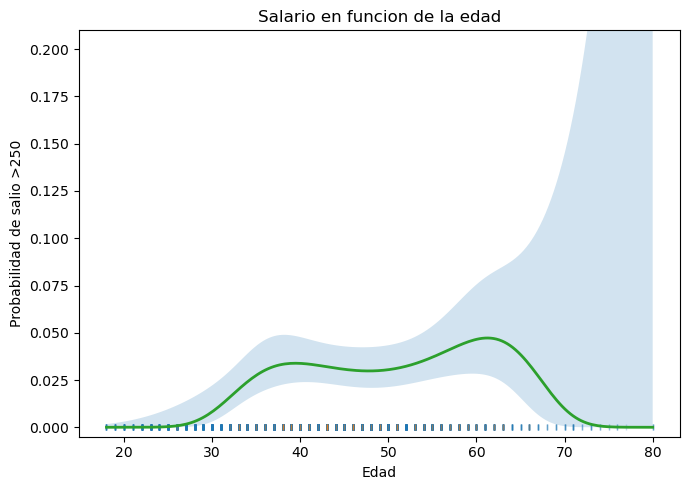

In [27]:
prob = resumen_logit['mean']
ic_lower = resumen_logit['mean_ci_lower']
ic_upper = resumen_logit['mean_ci_upper']
plt.figure(figsize = (7,5))
mask_bajo = wage['salario_alto'] == 0
plt.plot(wage.loc[mask_bajo, 'age'],
        np.zeros(mask_bajo.sum()),
         '|', alpha = 0.25, markersize = 5
        )

mask_alto = wage['salario_alto'] == 1
plt.plot(wage.loc[mask_alto, 'age'],
        np.zeros(mask_alto.sum()),
         '|', alpha = 0.25, markersize = 5
        )

plt.fill_between(age_grid, ic_lower, ic_upper, alpha = 0.2, label = 'IC 95%')

plt.plot(age_grid, prob, linewidth = 2, label = 'Regresion logistica polinomial')
plt.xlabel('Edad')
plt.ylabel('Probabilidad de salio >250')
plt.title('Salario en funcion de la edad')
plt.ylim(-0.005,0.21)
plt.tight_layout()
plt.show()

## Ejercicios de la practica

In [29]:
### Seleccion de modelo mediante AIC

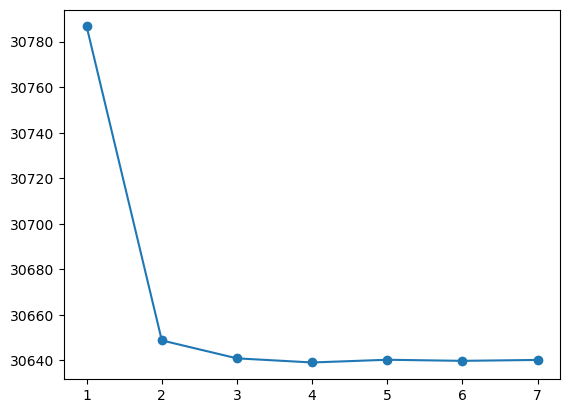

In [33]:
aic = []
for d in range(1,8):
    design_g4 = MS([poly('age',degree = d)])
    X_g4 = design_g4.fit_transform(wage)
    y = wage['wage']
    modelo_g4 = sm.OLS(y,X_g4).fit()
    aic.append(modelo_g4.aic)
    
plt.figure()
plt.plot(range(1,8),aic, marker = 'o')
plt.show()

¿Qué grado minimiza el AIC?

Parece ser el 6

¿Coincide con el grado sugerido por la comparación de modelos anidados?

No parece
¿Coincide con el obtenido mediante validación cruzada?

No

Expliquen brevemente por qué los tres criterios no tienen que producir necesariamente la misma respuesta.

Porque son mediciones diferentes.

### 2.13.2
Repitan el análisis utilizando year en lugar de age.

Ajusten modelos polinomiales de distintos grados y construyan una gráfica que permita comparar los ajustes.

¿Encuentran evidencia de una relación no lineal igual de fuerte que la observada para age?

Parece que no, porque al aumentar el grado modelo de maximiza el AIC

Justifiquen su respuesta utilizando tanto la gráfica como los resultados de los modelos.

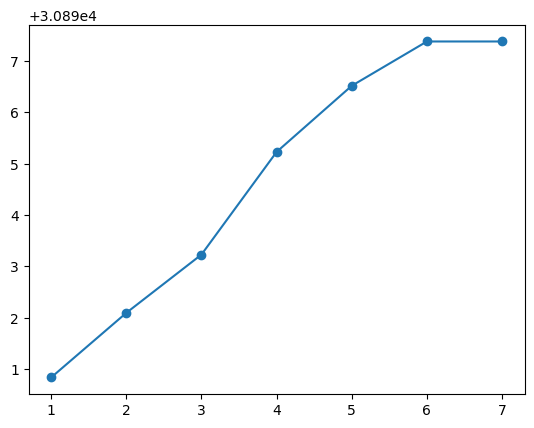

In [35]:
aic = []
for d in range(1,8):
    design_g4 = MS([poly('year',degree = d)])
    X_g4 = design_g4.fit_transform(wage)
    y = wage['wage']
    modelo_g4 = sm.OLS(y,X_g4).fit()
    aic.append(modelo_g4.aic)
    
plt.figure()
plt.plot(range(1,8),aic, marker = 'o')
plt.show()

### 2.13.3 Modelo con más predictores

Ajusten un modelo que incluya

poly('age', degree=3)

y la variable categórica

education

sin transformar.

Pueden construir la especificación mediante

MS([
    poly('age', degree=3),
    'education'
])

Interpreten brevemente el coeficiente asociado a uno de los niveles de education. 

que un cambio positivo en la educacion aumenta el salario

¿Qué representa ese coeficiente cuando mantenemos constante el efecto de la edad?
Que ha mayor educacion mas salario

In [40]:
design_g3 = MS([poly('age',degree = 3), 'education'])
X_g3 = design_g3.fit_transform(wage)
y = wage['wage']
modelo_g3 = sm.OLS(y,X_g3).fit()

summarize(modelo_g3)

,coef,std err,t,P>|t|
intercept,80.8925,1.257,64.365,0.00
"poly(age, degree=3)[0]",374.8353,35.492,10.561,0.00
"poly(age, degree=3)[1]",-380.1009,35.568,-10.687,0.00
"poly(age, degree=3)[2]",77.0700,35.442,2.175,0.03
education,15.3289,0.536,28.586,0.00


### 2.13.4 Depuración dirigida
Supongan que, durante la sección de validación cruzada, hubieran escrito

poly = PolynomialFeatures(degree=4)

en lugar de utilizar el nombre transformador_poly.

Sin ejecutar código:

Expliquen qué problema produciría esta instrucción.
Identifiquen en qué parte de la sección de regresión logística se manifestaría el error.
Expliquen por qué Python produciría ese error.


En primer lugar ya que importamos la instrucción "poly" de la paqueteria se confundiria al no sabe si es una variable o una función, en la parte justa en la que declaras la variable, ademas si cambias el nombre de poly  al declarar pero no cuando lo usas eso tambien generaria un error, porque no sabria difereciar entre la variable que declaramos y la funcion que importamos

### 2.13.5 Interpretación del efecto de la edad
La tabla producida por

summarize(modelo_g4)

muestra los coeficientes correspondientes a una base de polinomios ortogonales.

Expliquen por qué esta tabla no permite responder directamente:

¿Cuál es el cambio esperado en el salario cuando la edad aumenta un año?

No lo permite saber porque los coeficientes estan en una funcion polinomial, por lo que un pequeño cambio en la edad puede aumentar mucho o poco el salario


¿Qué cantidad relacionada con la curva f(x) deberían estudiar para responder esta pregunta?
la parte del coficiente del primer grado, aunque de forma incompleta.

¿Esperarían que ese efecto fuera el mismo para una persona de 25 años que para una de 60 años? Justifiquen.
No, ya que una persona de 25 a 26 puede cambiar mucho su salario por el crecimiento profesional, en cambio una persona de 60 años sea menos el efecto o incluso puede llegar a disminuir el salario.